In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle


Analyse the correlation b/w the performance of the networks with different weights and different memory capacity measurements

In [2]:
import wandb

api = wandb.Api()

!export WANDB_API_KEY=d40292fde8c59aa4440c
# %env WANDB_API_KEY=YOUR_NEW_KEY

wandb.login()

wandb: Currently logged in as: lilly-reisig (xiaoxionglin-bernstein-center-freiburg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
runs = api.runs("xiaoxionglin-bernstein-center-freiburg/SF_dmlab_rnn_random_lora_47")
all_results=dict()

In [4]:

weight_trials = [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49]
n_seeds = 5
n_policies = 4
seeds = [1111,2222,3333, 4444,5555]

In [5]:
runs = sorted(runs, key=lambda run: run.config['weight_trial'])

In [6]:
dfs = []
regex = r'raw|reward_min$|len/len$|lenweighted_score$|global_step$'
n_categories = regex.count('|') + 1
categories = ['len', 'raw_score', 'lenweighted_score', 'reward_min']
n_policies = 4



for idx, run in enumerate(runs):
    if run.config['seed'] == 1111:
        print('new df')
        df_seeds = {1111:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                    2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                    3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
                    4444:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
                    5555:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
    # extract the relevant data for this run, and store it in the corresponding weight trial dataframe
    weight_trial = run.config['weight_trial']
    print(weight_trial)
    print(run.config['seed'])
    cols = pd.Series(run.summary.keys())
    filtered = cols[cols.str.contains(regex, regex=True)].tolist()  # list of metric keys ordered by policy

    if (len(filtered)<n_categories*n_policies):
        print(f'run {run} did not run correctly and is skipped')
        continue
    #if not ('0/global_step' in cols.values):
    #    print(f'run {run} did not run correctly and is skipped')
    #    continue

    # the runs are now sorted by their weight trials, and within the run we now go through all categories for each policy
    for j in range(1, n_categories):
        dfs = []
        for i in range(n_policies):
            tmpdf2 = run.history(keys=filtered[i*n_categories:i*n_categories+j+1:j],samples=100000,pandas=True)  # time series of the selected metrics
            #if tmpdf2.empty:
            #    print(f'run {run} did not run correctly and is skipped')
            #    continue
            tmpdf=tmpdf2.groupby(tmpdf2[filtered[i*n_categories]].apply(lambda x: 30000*(x//30000)))[filtered[i*n_categories+j]].mean().reset_index(name=filtered[i*n_categories+j])  # smooth and time bin tmpdf2
            # format of tmpdf: binned global step | mean metric value
            #print(tmpdf.keys())
            dfs.append(tmpdf)
        
        parts = []
        for df in dfs:
            df.set_index(df.columns[0], inplace=True, drop=True)
            parts.append(df)
        union_idx = parts[0].index
        for part in parts[1:]:
            union_idx = union_idx.union(part.index)
        aligned = []
        for part in parts:
            part2 = part.reindex(union_idx)
            part2_interp = part2.interpolate(method='index', limit_direction='both')
            aligned.append(part2_interp)
        df_seeds[run.config['seed']][categories[j-1]] = pd.concat(aligned, axis=1)
    all_results[weight_trial] = df_seeds
        


new df
1
1111
1
2222
1
3333
1
4444
1
5555
new df
3
1111
3
2222
3
3333
3
4444
3
5555
new df
4
1111
4
2222
4
3333
4
4444
4
5555
new df
5
1111
5
2222
5
3333
5
4444
5
5555
new df
6
1111
6
2222
6
3333
6
4444
6
5555
new df
7
1111
7
2222
7
3333
7
4444
7
5555
new df
8
1111
8
2222
8
3333
8
4444
8
5555
new df
9
1111
9
2222
9
3333
9
4444
9
5555
new df
11
1111
11
2222
11
3333
11
4444
11
5555
new df
12
1111
12
2222
12
3333
12
4444
12
5555
new df
13
1111
13
2222
13
3333
13
4444
13
5555
new df
14
1111
14
2222
14
3333
14
4444
14
5555
new df
15
1111
15
2222
15
3333
15
4444
15
5555
new df
17
1111
17
2222
17
3333
17
4444
17
5555
new df
18
1111
18
2222
18
3333
18
4444
18
5555
new df
22
1111
22
2222
22
3333
22
4444
22
5555
new df
23
1111
23
2222
23
3333
23
4444
23
5555
new df
24
1111
24
2222
24
3333
24
4444
24
5555
new df
27
1111
27
2222
27
3333
27
4444
27
5555
new df
28
1111
28
2222
28
3333
28
4444
28
5555
new df
29
1111
29
2222
29
3333
29
4444
29
5555
new df
30
1111
30
2222
30
3333
30
4444
30
5555
new df

In [12]:
dfs = []
regex = r'raw|reward_min$|len/len$|lenweighted_score$|global_step$'
n_categories = regex.count('|') + 1
categories = ['len', 'raw_score', 'lenweighted_score', 'reward_min']
cols = pd.Series(runs[124].summary.keys())
filtered = cols[cols.str.contains(regex, regex=True)].tolist() 
print(filtered)
'''
for j in range(1, n_categories):
        dfs = []
        for i in range(n_policies):
                tmpdf2 = runs[124].history(keys=filtered[i*n_categories:i*n_categories+j+1:j],samples=100000,pandas=True)
                print(tmpdf2.empty)
                print(tmpdf2.keys())
'''
cols = pd.Series(runs[123].summary.keys())
filtered = cols[cols.str.contains(regex, regex=True)].tolist() 
print(filtered)
print(len(filtered))
tmpdf2 = runs[123].history(keys=filtered[0*n_categories:0*n_categories+1+1:1],samples=100000,pandas=True)
print(tmpdf2.empty)
print(tmpdf2.keys())

['0/global_step', '1/global_step', '2/global_step', '3/global_step']
['0/global_step', '0/len/len', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score', '0/reward/reward_min', '1/global_step', '1/len/len', '1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score', '1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score', '1/reward/reward_min', '2/global_step', '2/len/len', '2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score', '2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score', '2/reward/reward_min', '3/global_step', '3/len/len', '3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score', '3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score', '3/reward/reward_min']
20
False
Index(['_step', '0/global_step', '0/len/len'], dtype='object')


In [43]:
print(runs[124])
print(runs[124].config['weight_trial'])
#for j in range(1, n_categories):
#        dfs = []
#        for i in range(n_policies):
                
tmpdf2 = runs[1].history(keys=filtered[0*n_categories:0*n_categories+1+1:1],samples=100000,pandas=True)
print(tmpdf2.empty)
print(tmpdf2.keys().empty)
#tmpdf=tmpdf2.groupby(tmpdf2[filtered[0*n_categories]].apply(lambda x: 30000*(x//30000)))[filtered[0*n_categories+1]].mean().reset_index(name=filtered[0*n_categories+j]) 

<Run xiaoxionglin-bernstein-center-freiburg/SF_dmlab_rnn_random_lora_47/163_RNNRandomLORA47_see_5555_w.tri_36_20260121_044757_415353 (crashed)>
36
True
True


In [9]:
print(all_results.keys())

'''
data structure all_results:
number of weight trials, each containing a dict for each policy (4), all contain corresponding to the policy:
Index(['0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min', '0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min', '0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min'],
      dtype='object')
'''
print(all_results[36][5555])

dict_keys([1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49])
{'raw_score': None, 'lenweighted_score': None, 'reward_min': None, 'len': None}


In [10]:
# save the extracted data
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim47.pkl", "wb") as f:
    pickle.dump(all_results, f)

#### take the mean weight trial

In [5]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim44.pkl", "rb") as f:
    all_results = pickle.load(f)

In [9]:
print(all_results[1][0].keys())

Index(['0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min', '0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min', '0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min'],
      dtype='object')


In [12]:
c = all_results.copy()

In [ ]:
print(len(c[1][0]))
df_mean = c[1][0].T.groupby(level=0).mean().T
print(df_mean.keys())
print(len(df_mean))

5099
Index(['0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min'],
      dtype='object')
5099
Index(['0/len/len',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score',
       '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score',
       '0/reward/reward_min'],
      dtype='object')


In [31]:
mean_results = dict()

for trial in weight_trials:
    dfs_by_mean_policy = dict()
    for policy in range(n_policies):
        dfs_by_mean_policy[policy] = all_results[trial][policy].T.groupby(level=0).mean().T
    mean_results[trial] = dfs_by_mean_policy

In [33]:
print(mean_results[1][0])

                 0/len/len  \
0/global_step                
840000.0       6331.300000   
870000.0       6371.913333   
900000.0       6393.753333   
930000.0       6422.833333   
960000.0       6481.186667   
...                    ...   
154680000.0    2058.130000   
154710000.0    2013.565556   
154740000.0    2017.438889   
154770000.0    2026.882889   
154800000.0    2063.596667   

               0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score  \
0/global_step                                                                      
840000.0                                                0.783333                   
870000.0                                                0.750000                   
900000.0                                                0.750000                   
930000.0                                                0.683333                   
960000.0                                                0.633333                   
...                  

0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score


Text(0.5, 1.0, 'Length Weighted Score over Global Steps for Different Policies')

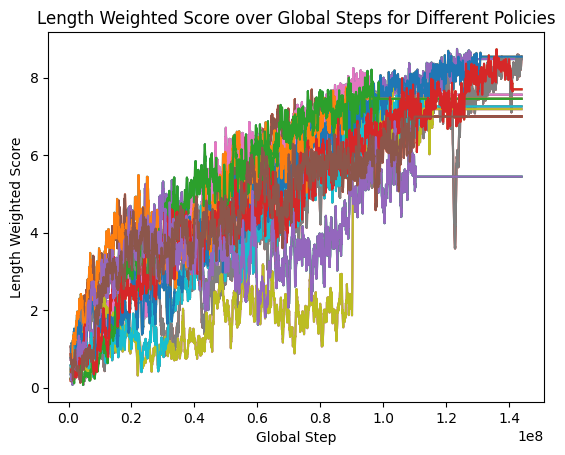

In [ ]:
# try out the unfiltered plotting with no gaussian smoothing, only the mean over bins

columns_to_plot = 'lenweighted_score'
filtered_columns = [c for c in result.columns if columns_to_plot in c]

plt.figure()
for col in filtered_columns:
    #print(col)
    plt.plot(result.index, result[col], label=col)

plt.xlabel('Global Step')
plt.ylabel('Length Weighted Score')
plt.title('Length Weighted Score over Global Steps for Different Policies')
#plt.legend()